In [ ]:

# =============================
# 1. Импорт библиотек
# =============================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer, OneHotEncoder
from sklearn.metrics import silhouette_score

# Опции отображения DataFrame
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1200)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


In [2]:

# =============================
# 2. Загрузка исходных данных
# =============================

df = pd.read_excel('./incidents_2000.xlsx')
df.head()

,Тип предприятия,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Регион размещения предприятия,Дата инцидента,Региональное время
0,НКО,1825,251,190,1,Республика Марий,02.04.2024,02.04.2024 07:47
1,химия,8936,378,152,1,Республика Адыгея,03.03.2023,03.03.2023 05:13
2,отели,8280,1432,7,0,Севастополь,09.05.2025,09.05.2025 10:28
3,фармацевтика,4558,1857,223,0,Смоленская область,15.05.2025,15.05.2025 13:17
4,энергетика,3528,1763,87,0,Архангельская область,17.02.2025,17.02.2025 06:22


In [3]:
data = pd.read_excel('./ФСТЭК.xlsx', header=1)
data.head()

,Идентификатор УБИ,Наименование УБИ,Описание,Источник угрозы (характеристика и потенциал нарушителя),Объект воздействия,Нарушение конфиденциальности,Нарушение целостности,Нарушение доступности,Дата включения угрозы в БнД УБИ,Дата последнего изменения данных,Статус угрозы,Замечания
0,1,Угроза автоматического распространения вредоно...,Угроза заключается в возможности внедрения и з...,Внешний нарушитель со средним потенциалом; Вну...,Ресурсные центры грид-системы,1,1,1,2015-03-20,2019-02-08,Опубликована,NaN
1,2,"Угроза агрегирования данных, передаваемых в гр...",Угроза заключается в возможности раскрытия нар...,Внешний нарушитель со средним потенциалом,Сетевой трафик,1,0,0,2015-03-20,2019-02-08,Опубликована,NaN
2,3,Угроза использования слабостей криптографическ...,Угроза заключается в возможности выявления сла...,Внешний нарушитель со средним потенциалом; Вну...,"Метаданные, системное программное обеспечение",1,1,0,2015-03-20,2020-11-29,Опубликована,NaN
3,4,Угроза аппаратного сброса пароля BIOS,Угроза заключается в возможности сброса пароле...,Внутренний нарушитель с низким потенциалом,Микропрограммное и аппаратное обеспечение BIOS...,0,1,0,2015-03-20,2019-02-08,Опубликована,NaN
4,5,Угроза внедрения вредоносного кода в BIOS,Угроза заключается в возможности заставить BIO...,Внутренний нарушитель с высоким потенциалом,Микропрограммное и аппаратное обеспечение BIOS...,1,1,1,2015-03-20,2019-02-08,Опубликована,NaN


In [4]:

# =============================
# 3. Объединение таблиц
# =============================
# Присоединяем признаки угроз из справочника ФСТЭК к журналу инцидентов.

df = df.merge(
    data,
    left_on="Код реализованной угрозы",
    right_on="Идентификатор УБИ",
    how="left"
)
df.head()


,Тип предприятия,Код предприятия,Количество хостов,Код реализованной угрозы,Успех,Регион размещения предприятия,Дата инцидента,Региональное время,Идентификатор УБИ,Наименование УБИ,Описание,Источник угрозы (характеристика и потенциал нарушителя),Объект воздействия,Нарушение конфиденциальности,Нарушение целостности,Нарушение доступности,Дата включения угрозы в БнД УБИ,Дата последнего изменения данных,Статус угрозы,Замечания
0,НКО,1825,251,190,1,Республика Марий,02.04.2024,02.04.2024 07:47,190,Угроза внедрения вредоносного кода за счет пос...,Угроза заключается в возможности осуществления...,Внешний нарушитель со средним потенциалом,Сетевое программное обеспечение,1,1,1,2016-10-21,2019-02-08,Опубликована,NaN
1,химия,8936,378,152,1,Республика Адыгея,03.03.2023,03.03.2023 05:13,152,Угроза удаления аутентификационной информации,Угроза заключается в возможности отказа легити...,Внешний нарушитель с низким потенциалом; Внутр...,"Системное программное обеспечение, микропрогра...",1,1,1,2015-03-20,2019-02-11,Опубликована,NaN
2,отели,8280,1432,7,0,Севастополь,09.05.2025,09.05.2025 10:28,7,Угроза воздействия на программы с высокими при...,Угроза заключается в возможности повышения нар...,Внешний нарушитель со средним потенциалом; Вну...,"Информационная система, виртуальная машина, се...",1,1,0,2015-03-20,2019-02-08,Опубликована,NaN
3,фармацевтика,4558,1857,223,0,Смоленская область,15.05.2025,15.05.2025 13:17,223,Угроза несанкционированного доступа к контейне...,Угроза заключается в возможности осуществления...,Внешний нарушитель с низким потенциалом; Внутр...,Docker-контейнер,1,1,1,2025-06-04,2025-06-04,Опубликована,NaN
4,энергетика,3528,1763,87,0,Архангельская область,17.02.2025,17.02.2025 06:22,87,Угроза несанкционированного использования прив...,Угроза заключается в возможности использования...,Внешний нарушитель с высоким потенциалом; Внут...,"Аппаратное обеспечение, микропрограммное обесп...",1,1,1,2015-03-20,2019-02-11,Опубликована,NaN


In [5]:

# =============================
# 4. Первичная очистка
# =============================
# Удаляем архивные угрозы и исправляем неправилтные колонки предприятий
# через группировку по коду предприятия.

df = df[df['Статус угрозы'] != 'Архивная']
df[['Количество хостов', 'Регион размещения предприятия', 'Тип предприятия']] = df\
    .groupby('Код предприятия')[['Количество хостов', 'Регион размещения предприятия', 'Тип предприятия']]\
    .transform('first')


In [6]:

# =============================
# 5. Преобразование даты и удаление служебных полей
# =============================
# Дата инцидента полезна как источник производных признаков.
df['Дата инцидента'] = pd.to_datetime(df['Дата инцидента'], format="%d.%m.%Y")
df['Год'] = df['Дата инцидента'].dt.year
df['Месяц'] = df['Дата инцидента'].dt.month
df['День'] = df['Дата инцидента'].dt.day
df['День недели'] = df['Дата инцидента'].dt.weekday

# Удаляем поля, которые либо являются идентификаторами,
# либо являются чисто служебными и не должны влиять на кластеризацию.
df = df.drop(['Дата инцидента', 'Региональное время', 'Код предприятия', 'Идентификатор УБИ', 
            'Дата включения угрозы в БнД УБИ', 'Дата последнего изменения данных', 'Статус угрозы', 
            'Замечания', 'Наименование УБИ', 'Описание'], axis=1)


In [7]:

# =============================
# 6. Работа с пропусками
# =============================
# Используется полное удаление строк с пропусками

df = df.dropna()
df = df.reset_index(drop=True)

In [8]:

# =============================
# 7. Кодирование мультизначных категориальных полей
# =============================
# Эти столбцы содержат списки объектов / источников угроз.
# Для кластеризации их нужно развернуть в бинарные признаки.

df['Объект воздействия'] = df['Объект воздействия'].str.split(', ')
df['Источник угрозы (характеристика и потенциал нарушителя)'] = df['Источник угрозы (характеристика и потенциал нарушителя)'].str.split('; ')

mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(df['Объект воздействия'])
encoded_df = pd.DataFrame(encoded, columns=mlb.classes_)
df = pd.concat([df, encoded_df], axis=1)

encoded = mlb.fit_transform(df['Источник угрозы (характеристика и потенциал нарушителя)'])
encoded_df = pd.DataFrame(encoded, columns=mlb.classes_)
df = pd.concat([df, encoded_df], axis=1)

df = df.drop(['Объект воздействия', 'Источник угрозы (характеристика и потенциал нарушителя)'], axis=1)


In [9]:

# =============================
# 8. Кодирование обычных категориальных признаков
# =============================
# Для малокатегориальных столбцов используем One-Hot Encoding, для остальных Frequency Encoding.

ohe = OneHotEncoder()
row_data = ohe.fit_transform(df[['Тип предприятия']]).toarray()
df_one_hot = pd.DataFrame(row_data, columns=[i[j] for i in ohe.categories_ for j in range(len(i))])
df = pd.concat([df, df_one_hot], axis=1)
df = df.drop(['Тип предприятия'], axis=1)

freq = df['Регион размещения предприятия'].value_counts(normalize=True)
df['Регион размещения предприятия'] = df['Регион размещения предприятия'].map(freq)


In [10]:

# =============================
# 9. Подготовка матрицы признаков
# =============================
# Нормализуем все признаки для дальнейшего использования

scaler = StandardScaler()
X = scaler.fit_transform(df)


In [11]:

# =============================
# 10. PCA только для визуализации
# =============================
# Снижаем размерность до 2 компонент для построения графиков.

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

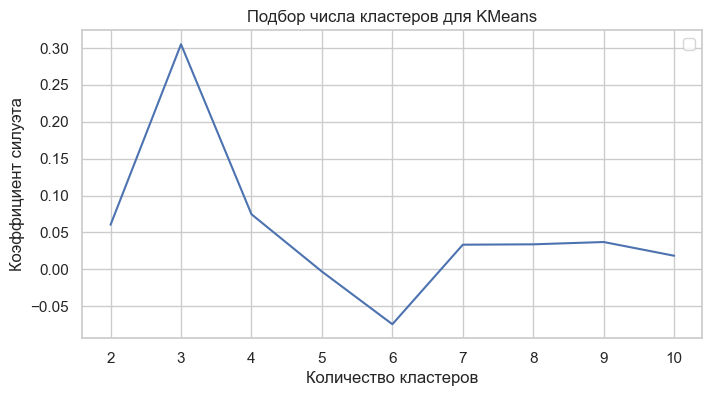

Лучшее число кластеров для KMeans по silhouette: 3


In [12]:

# =============================
# 11. Подбор числа кластеров для KMeans
# =============================

k_range = range(2, 11)
kmeans_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=5)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    kmeans_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_range, kmeans_scores)
plt.title('Подбор числа кластеров для KMeans')
plt.xlabel('Количество кластеров')
plt.ylabel('Коэффициент силуэта')
plt.legend()
plt.show()

best_k = list(k_range)[int(np.argmax(kmeans_scores))]
print('Лучшее число кластеров для KMeans по silhouette:', best_k)


In [13]:

# =============================
# 12. KMeans на исходных подготовленных данных
# =============================

kmeans_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=5)
kmeans_labels = kmeans_model.fit_predict(X)
kmeans_result = silhouette_score(X, kmeans_labels)
kmeans_result


0.30498941180242095

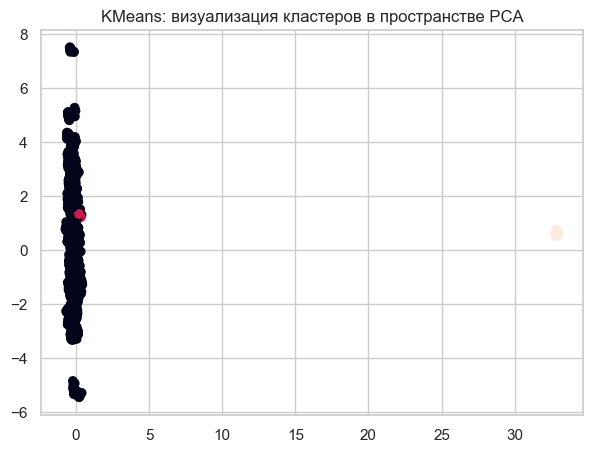

In [14]:
# Визуализация KMeans в PCA-пространстве
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title('KMeans: визуализация кластеров в пространстве PCA')
plt.show()


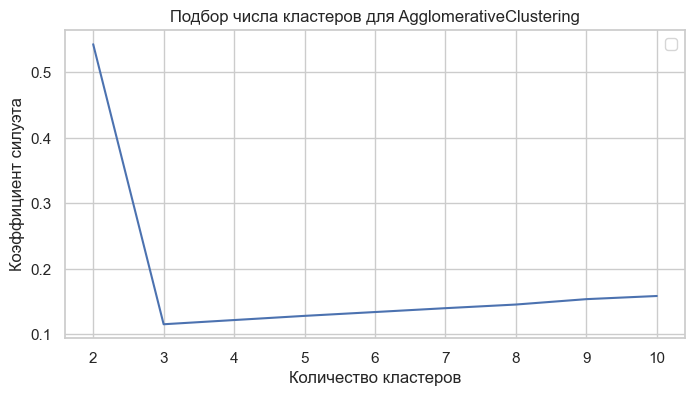

Лучшее число кластеров для AgglomerativeClustering: 2


In [15]:

# =============================
# 13. Agglomerative Clustering для сравнения
# =============================

agg_scores = []

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    agg_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_range, agg_scores)
plt.title('Подбор числа кластеров для AgglomerativeClustering')
plt.xlabel('Количество кластеров')
plt.ylabel('Коэффициент силуэта')
plt.legend()
plt.show()

best_k_agg = list(k_range)[int(np.argmax(agg_scores))]
print('Лучшее число кластеров для AgglomerativeClustering:', best_k_agg)


In [16]:
agg_model = AgglomerativeClustering(n_clusters=best_k_agg)
agg_labels = agg_model.fit_predict(X)
agg_result = silhouette_score(X, agg_labels)
agg_result


0.542919004981622

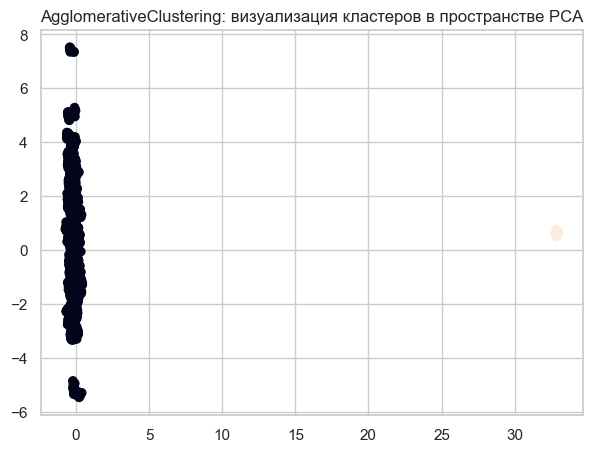

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels)
plt.title('AgglomerativeClustering: визуализация кластеров в пространстве PCA')
plt.show()

In [20]:

# =============================
# 14. DBSCAN для сравнения
# =============================

best_score = -1
best_params = None
eps_values = np.arange(0.1, 2.1, 0.1)
min_samples_values = range(3, 11)
for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)
        # пропускаем плохие случаи
        if len(set(labels)) <= 1:
            continue
        # silhouette не работает если есть только шум или 1 кластер
        if -1 in labels and len(set(labels)) == 2:
            continue
        score = silhouette_score(X, labels)
        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)

print('Best params:', best_params)
print('Best silhouette:', best_score)

Best params: (np.float64(2.0), 3)
Best silhouette: 0.08946509124027688


In [22]:
dbscan_model = DBSCAN(eps=best_params[0], min_samples=best_params[1])
dbscan_labels = dbscan_model.fit_predict(X)
dbscan_result = silhouette_score(X, dbscan_labels)
dbscan_result


0.08946509124027688

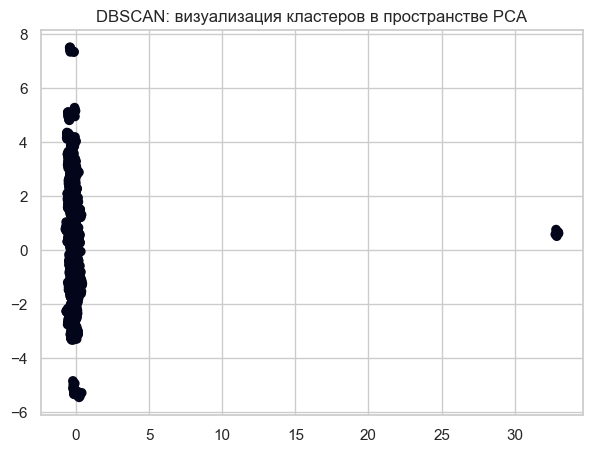

In [23]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels)
plt.title('DBSCAN: визуализация кластеров в пространстве PCA')
plt.show()